Weekly revenue is modeled as the sum of baseline demand, trend, promotion, yearly seasonality, and channel-specific media contributions after geometric adstock and logistic saturation.

$$ y_t \sim \mathcal{N}(\mu_t, \sigma) $$

$$ \mu_t = \alpha + \gamma_1 \,\text{promotion}_t + \gamma_2 \,\text{time\_index}_t +\text{seasonality}_t+ \sum_{m=1}^{3} \beta_m S_{\lambda_m} \left( A_{\alpha_m}(x_{t,m}) \right) $$

In [3]:
%pip install -U ipywidgets


[notice] A new release of pip is available: 24.3.1 -> 26.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd

from pymc_marketing.mmm import (GeometricAdstock, LogisticSaturation,)
from pymc_marketing.mmm.multidimensional import MMM

RANDOM_SEED = 20260801

train_df = pd.read_csv( "../data/scenario_a/scenario_a_train.csv", parse_dates=["date_week"],)

channel_columns = [ "tv_spend",   "google_search_spend",  "tiktok_spend", ]
control_columns = [  "promotion", "time_index", ]

X_train = train_df[ ["date_week", *channel_columns,  *control_columns, ] ].copy()
y_train = train_df["revenue"].copy()

mmm = MMM(
    date_column="date_week",
    target_column="revenue",
    channel_columns=channel_columns,
    control_columns=control_columns,
    adstock=GeometricAdstock(l_max=8),
    saturation=LogisticSaturation(),
    yearly_seasonality=2,
)
mmm

The standard PyMC-marketing MMM accepts one shared adstock transformation, so l_max is common across channels. Channel specific carryover is mainly captured through different adstock decay parameters. Exact channel specific maximum lags require a lower-level mediaconfiglist setup and a customized PyMC model.

l_max is a structural modeling choice rather than a parameter estimated by NUTS. The decay parameter is inferred from the data conditional on that maximum lag. I would choose a defensible baseline using domain knowledge, then compare alternative lag windows through time-based validation, residual diagnostics, and sensitivity analysis.

Why do we choose LogisticAdstock?
Hill saturation is more flexible because it has three parameters, but that flexibility can create identifiability problems. Different combinations of the maximum effect, half-saturation point, and slope may generate almost identical curves within the observed spend range. Logistic saturation is more parsimonious and is often easier to estimate, although it can still be weakly identified if the data do not cover enough of the saturation curve.

In [5]:
mmm.build_model(
    X=X_train,
    y=y_train,
)

print(mmm.model)

print("Coordinates:")
display(mmm.model.coords)

print("Named variables:")
for variable_name in mmm.model.named_vars:
    print(variable_name)

Coordinates:


{'date': (np.datetime64('2023-01-02T00:00:00.000000'),
  np.datetime64('2023-01-09T00:00:00.000000'),
  np.datetime64('2023-01-16T00:00:00.000000'),
  np.datetime64('2023-01-23T00:00:00.000000'),
  np.datetime64('2023-01-30T00:00:00.000000'),
  np.datetime64('2023-02-06T00:00:00.000000'),
  np.datetime64('2023-02-13T00:00:00.000000'),
  np.datetime64('2023-02-20T00:00:00.000000'),
  np.datetime64('2023-02-27T00:00:00.000000'),
  np.datetime64('2023-03-06T00:00:00.000000'),
  np.datetime64('2023-03-13T00:00:00.000000'),
  np.datetime64('2023-03-20T00:00:00.000000'),
  np.datetime64('2023-03-27T00:00:00.000000'),
  np.datetime64('2023-04-03T00:00:00.000000'),
  np.datetime64('2023-04-10T00:00:00.000000'),
  np.datetime64('2023-04-17T00:00:00.000000'),
  np.datetime64('2023-04-24T00:00:00.000000'),
  np.datetime64('2023-05-01T00:00:00.000000'),
  np.datetime64('2023-05-08T00:00:00.000000'),
  np.datetime64('2023-05-15T00:00:00.000000'),
  np.datetime64('2023-05-22T00:00:00.000000'),
  np.

Named variables:
channel_scale
target_scale
channel_data
target_data
intercept_contribution
adstock_alpha
saturation_lam
saturation_beta
channel_contribution
total_media_contribution_original_scale
gamma_control
control_data
control_contribution
dayofyear
gamma_fourier
fourier_contribution
yearly_seasonality_contribution
y_sigma
y


The model configuration defines priors for the intercept, control and seasonal effects, channel-specific adstock and saturation parameters, and the observation noise in the likelihood.

In [6]:
display(mmm.model_config)

{'intercept': Prior("Normal", mu=0, sigma=2, dims=()),
 'likelihood': Prior("Normal", sigma=Prior("HalfNormal", sigma=2, dims=()), dims="date"),
 'gamma_control': Prior("Normal", mu=0, sigma=2, dims="control"),
 'gamma_fourier': Prior("Laplace", mu=0, b=1, dims="fourier_mode"),
 'adstock_alpha': Prior("Beta", alpha=1, beta=3, dims="channel"),
 'saturation_lam': Prior("Gamma", alpha=3, beta=1, dims="channel"),
 'saturation_beta': Prior("HalfNormal", sigma=2, dims="channel")}

Prior predictive checks help verify that the priors imply plausible business outcomes before fitting the model.

In [7]:
_ = mmm.sample_prior_predictive(
    X=X_train,
    y=y_train,
    samples=500,
    random_seed=RANDOM_SEED,
)

Sampling: [adstock_alpha, gamma_control, gamma_fourier, intercept_contribution, saturation_beta, saturation_lam, y, y_sigma]


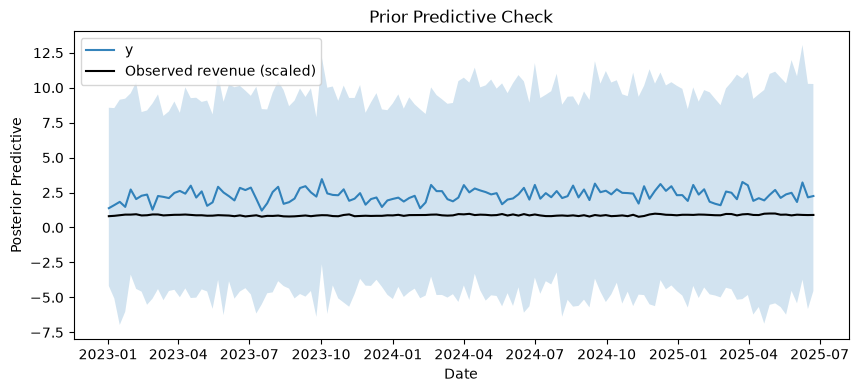

In [8]:
fig, axes = mmm.plot.prior_predictive(hdi_prob=0.94)

ax = axes.flatten()[0]

ax.plot(
    X_train["date_week"],
    y_train / y_train.max(),
    color="black",
    linewidth=1.5,
    label="Observed revenue (scaled)",
)

ax.set_title("Prior Predictive Check")
ax.legend()

The observed revenue falls within the prior predictive interval, but the default priors are quite broad and allow implausibly negative and very large outcomes.

In [9]:
mmm.fit(
    X=X_train,
    y=y_train,
    chains=4,
    tune=1000,
    draws=1000,
    target_accept=0.95,
    random_seed=RANDOM_SEED,
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept_contribution, adstock_alpha, saturation_lam, saturation_beta, gamma_control, gamma_fourier, y_sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 71 seconds.
There were 22 divergences after tuning. Increase `target_accept` or reparameterize.


Output()

Inference data with groups:
	> posterior
	> sample_stats
	> prior
	> prior_predictive
	> observed_data
	> constant_data
	> fit_data

## MCMC Sampling Parameters

### 1. `chains=4`

A chain is one independent MCMC sampling process.

Setting `chains=4` means that the model runs four separate chains, usually starting from different initial parameter values.

The purpose of using multiple chains is to check whether they all converge to the same posterior distribution. If the chains behave similarly, this provides evidence that the sampler has converged.

R-hat compares the variation within each chain with the variation across chains. Ideally, R-hat should be close to 1.

---

### 2. `tune=1500`

`tune` is the number of warm-up or adaptation iterations for each chain.

During these 1,500 iterations, NUTS learns how to explore the posterior efficiently by adjusting quantities such as:

- the step size;
- the mass matrix;
- the appropriate trajectory behavior.

These tuning samples are normally discarded and are not included in the final posterior samples.

The purpose of tuning is to prepare the sampler before collecting the actual posterior draws.

---

### 3. `draws=1000`

`draws` is the number of posterior samples retained from each chain after tuning is completed.

With four chains and 1,000 draws per chain, the model retains:

$4 \times 1000 = 4000$

posterior samples in total.

However, MCMC samples are usually correlated. Therefore, 4,000 posterior draws do not necessarily provide the same information as 4,000 independent samples. We use the effective sample size, or ESS, to measure the equivalent number of independent samples.

Each chain performs:

$1500\text{ tuning iterations} + 1000\text{ posterior draws} = 2500\text{ iterations}$

Across four chains, the total number of iterations is:

$4 \times 2500 = 10000$

---

### 4. `target_accept=0.95`

`target_accept` is the target average acceptance probability used by NUTS when tuning the step size.

After constructing a proposed move, NUTS calculates an acceptance probability:

$a = \min\left(1, e^{-\Delta H}\right)$

where $\Delta H$ is the numerical error in the Hamiltonian energy.

During tuning:

- if the average acceptance probability is below 0.95, the step size is probably too large, so NUTS decreases it;
- if the average acceptance probability is above 0.95, the step size may be unnecessarily small, so NUTS may increase it.

Therefore, `target_accept=0.95` means:

> During tuning, adjust the step size so that the average acceptance probability is approximately 95%.

It does not guarantee that exactly 95% of proposals will be accepted. It is a tuning target, not a strict requirement.

A higher `target_accept` usually leads to:

- a smaller step size;
- more cautious exploration;
- longer sampling time;
- fewer divergences.

However, increasing `target_accept` does not solve fundamental problems such as poor identifiability, inappropriate priors, or severe posterior correlations.

In [10]:
mmm.fit(
    X=X_train,
    y=y_train,
    chains=4,
    tune=1500,
    draws=1000,
    target_accept=0.95,
    random_seed=RANDOM_SEED,
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept_contribution, adstock_alpha, saturation_lam, saturation_beta, gamma_control, gamma_fourier, y_sigma]


Output()

Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 83 seconds.
There were 33 divergences after tuning. Increase `target_accept` or reparameterize.


Output()

Inference data with groups:
	> posterior
	> sample_stats
	> prior
	> prior_predictive
	> observed_data
	> constant_data
	> fit_data

A divergence occurs when NUTS enters a narrow or highly curved region of the posterior and its numerical path can no longer
follow that region accurately.

I would first increase target_accept to reduce the step size, then identify the problematic parameter combinations and improve the scaling, priors, parameterization, or model structure.

## Divergence in HMC and NUTS

### Mathematical setup

Let $q$ represent the model parameters and let $p$ represent an auxiliary momentum variable.

The potential energy is $U(q)=-\log p(q\mid y)$.

The kinetic energy is $K(p)=\frac{1}{2}p^\top M^{-1}p$.

The Hamiltonian is the sum of the potential and kinetic energies: $H(q,p)=U(q)+K(p)$.

Under exact continuous Hamiltonian dynamics, the Hamiltonian is conserved, so $H_{\mathrm{end}}=H_{\mathrm{start}}$ and therefore $\Delta H=H_{\mathrm{end}}-H_{\mathrm{start}}=0$.

In practice, NUTS uses a discrete numerical approximation, so a small error is normal and we expect $\Delta H\approx 0$.

A divergence occurs when the numerical error becomes abnormally large, meaning that $|\Delta H|$ is large and the simulated path can no longer accurately follow the posterior distribution.

### Why divergences occur

The immediate cause is usually that the step size is too large for a narrow or highly curved region of the posterior.

Common underlying causes include:

- strong posterior correlations;
- weakly identified parameters;
- parameters with very different scales;
- overly broad priors;
- highly correlated media channels;
- unnecessarily complex model structure.

In MMM, divergences may occur when different combinations of `adstock_alpha`, `saturation_lam`, and `channel_beta` produce almost the same response curve. This creates a narrow or curved posterior region that is difficult for NUTS to explore.

### Why we want zero divergences

A divergence indicates that NUTS may not have explored part of the posterior reliably.

The problem is not simply that one draw is lost. Divergences may be concentrated in a specific parameter region, so the sampler may systematically miss important combinations of parameters.

This can bias posterior summaries such as:

- channel contributions;
- credible intervals;
- adstock and saturation estimates;
- ROAS and marginal ROAS;
- budget recommendations.

Therefore, the practical goal is `post-tuning divergences = 0`.

Zero divergences do not prove that the model is correct, but nonzero divergences are clear evidence of a sampling problem.

### How to address divergences

First, increase `target_accept`, for example from `0.90` to `0.95` or `0.97`. This usually reduces the NUTS step size and makes the numerical path more cautious.

Second, inspect where the divergent draws occur. Useful parameter pairs in MMM include:

- `adstock_alpha` versus `saturation_lam`;
- `saturation_lam` versus `channel_beta`;
- coefficients of highly correlated channels;
- baseline versus media contribution.

Third, check the scaling of the target, media spend, and control variables. Very different numerical scales can make posterior exploration difficult.

Fourth, use more appropriate or more regularizing priors. Priors should prevent parameters from entering unrealistic extreme regions.

Fifth, reparameterize the model when possible. For hierarchical models, this may mean using a non-centered parameterization.

Sixth, simplify the model if the data cannot identify all parameters. Possible actions include using a simpler saturation function, reducing the number of free parameters, shortening the lag structure, or combining highly correlated channels.

Increasing `tune` can give NUTS more time to adapt, but simply increasing `draws` does not fix divergences.

In [11]:
mmm.fit(
    X=X_train,
    y=y_train,
    chains=4,
    tune=1500,
    draws=500,
    target_accept=0.99,
    random_seed=RANDOM_SEED,
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept_contribution, adstock_alpha, saturation_lam, saturation_beta, gamma_control, gamma_fourier, y_sigma]


Output()

Sampling 4 chains for 1_500 tune and 500 draw iterations (6_000 + 2_000 draws total) took 103 seconds.
There were 4 divergences after tuning. Increase `target_accept` or reparameterize.


Output()

Inference data with groups:
	> posterior
	> sample_stats
	> prior
	> prior_predictive
	> observed_data
	> constant_data
	> fit_data

Increasing target_accept from 0.95 to 0.99 substantially reduced the divergence rate, but four post-warmup divergences remained, so the sampling configuration still required refinement.

In [12]:
mmm.fit(
    X=X_train,
    y=y_train,
    chains=4,
    tune=2000,
    draws=1000,
    target_accept=0.995,
    random_seed=RANDOM_SEED,
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept_contribution, adstock_alpha, saturation_lam, saturation_beta, gamma_control, gamma_fourier, y_sigma]


Output()

Sampling 4 chains for 2_000 tune and 1_000 draw iterations (8_000 + 4_000 draws total) took 201 seconds.
There were 10 divergences after tuning. Increase `target_accept` or reparameterize.


Output()

Inference data with groups:
	> posterior
	> sample_stats
	> prior
	> prior_predictive
	> observed_data
	> constant_data
	> fit_data

Divergences: 10/4000 (0.25%)


,mean,sd,r_hat,ess_bulk,ess_tail
adstock_alpha[tv_spend],0.370,0.109,1.000,3433.007,2012.797
adstock_alpha[google_search_spend],0.250,0.182,1.001,3110.605,1888.956
adstock_alpha[tiktok_spend],0.173,0.127,1.001,3601.515,1941.009
saturation_lam[tv_spend],2.037,1.372,0.999,2053.723,1451.782
saturation_lam[google_search_spend],2.993,2.101,1.006,715.694,484.768
saturation_lam[tiktok_spend],1.777,1.253,1.001,2226.913,2048.783
saturation_beta[tv_spend],0.165,0.198,1.000,1871.345,1432.596
saturation_beta[google_search_spend],0.115,0.121,1.006,837.079,453.220
saturation_beta[tiktok_spend],0.100,0.117,1.002,2128.671,2116.304
gamma_control[promotion],0.075,0.006,1.000,4769.112,3071.445


BFMI by chain:
[0.87770669 0.93794124 0.87175187 0.84315262]


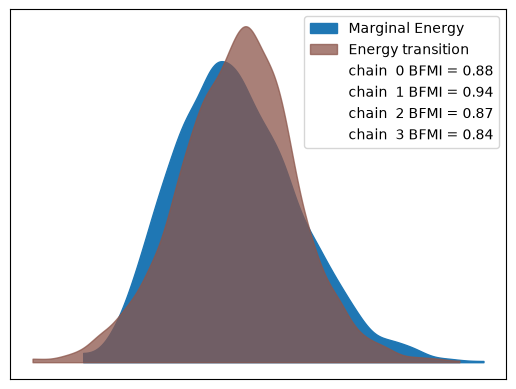

In [13]:
import arviz as az

idata = mmm.idata

n_divergences = int(
    idata["sample_stats"]["diverging"].sum().item()
)

n_samples = (
    idata["sample_stats"].sizes["chain"]
    * idata["sample_stats"].sizes["draw"]
)

print(
    f"Divergences: {n_divergences}/{n_samples} "
    f"({n_divergences / n_samples:.2%})"
)

diagnostic_vars = [
    "adstock_alpha",
    "saturation_lam",
    "saturation_beta",
    "gamma_control",
    "gamma_fourier",
    "y_sigma",
]

summary = az.summary(
    idata,
    var_names=diagnostic_vars,
    round_to=3,
)

display(
    summary[
        [
            "mean",
            "sd",
            "r_hat",
            "ess_bulk",
            "ess_tail",
        ]
    ]
)

print("BFMI by chain:")
print(az.bfmi(idata))

az.plot_energy(idata);

I did not conclude that the entire Google Search channel was problematic. I identified its saturation parameters as the first candidates for investigation because they had the highest R-hat values and substantially lower bulk and tail ESS than the corresponding parameters for TV and TikTok.

## MCMC Convergence Diagnostics

### 1. R-hat

R-hat checks whether multiple MCMC chains have converged to the same posterior distribution.

Suppose there are $M$ chains with $N$ draws per chain. Let $\bar{\theta}_m$ be the mean of chain $m$, and let $\bar{\theta}$ be the mean across all chains.

The within-chain variance is $W=\frac{1}{M}\sum_{m=1}^{M}s_m^2$, where $s_m^2$ is the variance within chain $m$.

The between-chain variance is $B=\frac{N}{M-1}\sum_{m=1}^{M}(\bar{\theta}_m-\bar{\theta})^2$.

The estimated total posterior variance is $\widehat{V}=\frac{N-1}{N}W+\frac{1}{N}B$.

The basic R-hat statistic is $\widehat{R}=\sqrt{\frac{\widehat{V}}{W}}$.

If all chains explore the same posterior distribution, the between-chain and within-chain variations should be similar, so $\widehat{R}\approx1$.

**Purpose:** R-hat detects whether different chains have failed to converge to the same posterior distribution.

**Acceptable range:** PyMC-Marketing recommends $\widehat{R}<1.01$ for every monitored parameter.

**Current result:** The reported R-hat values range from approximately $0.999$ to $1.006$, so all reported parameters pass the R-hat criterion.



### 2. Effective Sample Size

MCMC draws are usually autocorrelated, so the total number of draws is not equal to the number of independent samples.

For $M$ chains with $N$ draws per chain, the effective sample size is approximately $N_{\mathrm{eff}}=\frac{MN}{\widehat{\tau}}$, where $\widehat{\tau}$ is the estimated integrated autocorrelation time.

Conceptually, the integrated autocorrelation time is $\widehat{\tau}\approx1+2\sum_{t=1}^{\infty}\widehat{\rho}_t$, where $\widehat{\rho}_t$ is the estimated autocorrelation at lag $t$.

If autocorrelation is high, then $\widehat{\tau}$ is large and $N_{\mathrm{eff}}$ becomes much smaller than the total number of posterior draws.

**Purpose:** ESS measures how much independent information is contained in the correlated MCMC draws.

### How Integrated Autocorrelation Time Is Estimated

Suppose an MCMC chain produces samples $\theta_1,\theta_2,\ldots,\theta_N$ for one model parameter.

First, calculate the sample mean as $\bar{\theta}=\frac{1}{N}\sum_{t=1}^{N}\theta_t$.

Next, calculate the sample autocovariance at lag $k$:

$\widehat{\gamma}_k=\frac{1}{N-k}\sum_{t=1}^{N-k}(\theta_t-\bar{\theta})(\theta_{t+k}-\bar{\theta})$.

Here, lag $k=1$ compares adjacent draws, lag $k=2$ compares draws separated by two positions, and so on.

The autocorrelation at lag $k$ is then estimated as $\widehat{\rho}_k=\frac{\widehat{\gamma}_k}{\widehat{\gamma}_0}$, where $\widehat{\gamma}_0$ is the sample variance.

The integrated autocorrelation time is estimated as $\widehat{\tau}=1+2\sum_{k=1}^{\infty}\widehat{\rho}_k$.

It measures how many correlated MCMC draws contain approximately the same amount of information as one independent draw.

For example, suppose $\widehat{\rho}_1=0.5$, $\widehat{\rho}_2=0.25$, and $\widehat{\rho}_3=0.10$, while the remaining autocorrelations are close to zero. Then $\widehat{\tau}\approx1+2(0.5+0.25+0.10)=2.7$.

This means that approximately $2.7$ correlated MCMC draws provide the same amount of information as one independent draw.

If four chains contain $4000$ posterior draws in total, the effective sample size is approximately $N_{\mathrm{eff}}=\frac{4000}{2.7}\approx1481$.

In practice, the autocorrelation sum is not continued to infinity. At large lags, estimated autocorrelations become noisy. ArviZ uses a stable truncation procedure and combines information from multiple chains when estimating ESS.

The overall calculation is:

`posterior draws → estimate autocorrelation at different lags → calculate integrated autocorrelation time → divide the total number of draws by this value to obtain ESS`

### 3. ESS Bulk

ESS bulk measures the effective sample size in the central region of the posterior distribution.

**Purpose:** It evaluates how accurately the sampler estimates quantities mainly determined by the center of the posterior, including posterior means, medians, standard deviations, and the central region of credible intervals.

A low ESS bulk means that the chains move slowly through the main posterior region and provide relatively little independent information.

**Acceptable range:** PyMC-Marketing recommends `ess_bulk > 400` for every monitored parameter.




### 4. ESS Tail

ESS tail measures how effectively the sampler explores the lower and upper tails of the posterior distribution.

ArviZ evaluates the effective sample sizes near the $5\%$ and $95\%$ posterior quantiles and reports approximately $\mathrm{ESS}_{\mathrm{tail}}=\min(\mathrm{ESS}_{5\%},\mathrm{ESS}_{95\%})$.

**Purpose:** It evaluates the reliability of credible interval boundaries, extreme posterior quantiles, and tail probabilities.

A model can have a good ESS bulk but a poor ESS tail when the sampler explores the center well but does not explore the extreme posterior regions effectively.

**Acceptable range:** PyMC-Marketing recommends `ess_tail > 400` for every monitored parameter.

### 5. BFMI

BFMI stands for Bayesian Fraction of Missing Information.

An estimated BFMI is $\widehat{\mathrm{BFMI}}=\frac{\operatorname{mean}[(E_n-E_{n-1})^2]}{\operatorname{Var}(E_n)}$, where $E_n$ is the Hamiltonian energy at draw $n$.

The numerator measures how much the energy changes between consecutive draws, while the denominator measures the total variation in the energy distribution that the chain needs to explore.

**Purpose:** BFMI checks whether each HMC chain moves effectively across the energy levels of the posterior distribution.

A commonly used warning threshold is $\mathrm{BFMI}<0.3$. Values below this threshold suggest that a chain is not exploring the posterior energy distribution effectively.

Low BFMI means the sampler has enough energy range to explore, but each step changes energy too little, so it keeps moving locally instead of traveling effectively across the posterior.

### Overall Interpretation

All reported R-hat values satisfy $\widehat{R}<1.01$, all ESS bulk values are above $400$, all ESS tail values are above $400$, and all BFMI values are well above $0.3$.

Divergences by chain:
[0 6 1 3]


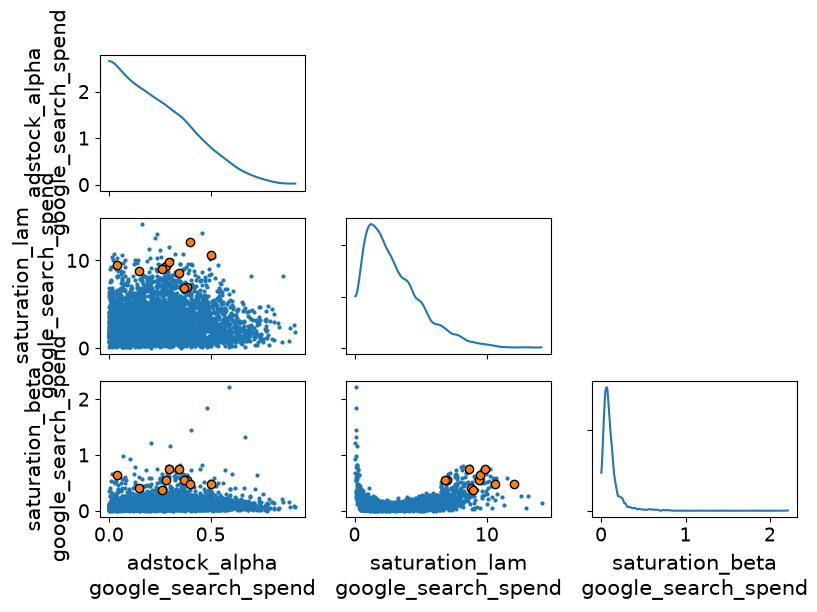

In [14]:
idata = mmm.idata

print("Divergences by chain:")
print(
    idata["sample_stats"]["diverging"]
    .sum(dim="draw")
    .values
)

az.plot_pair(
    idata,
    var_names=[
        "adstock_alpha",
        "saturation_lam",
        "saturation_beta",
    ],
    coords={
        "channel": ["google_search_spend"]
    },
    kind="scatter",
    marginals=True,
    divergences=True,
    figsize=(9, 6),
);

The pair plot shows a strong nonlinear dependence between the Google Search saturation parameters. Different combinations of saturation_lam and saturation_beta appear to produce similar response curves within the observed spend range. The divergent transitions are concentrated in the high-lambda and moderate-to-high-beta region, indicating a localized posterior geometry and weak-identification problem rather than overall chain non-convergence.

## Regularized Model

In [15]:
from pymc_extras.prior import Prior

In [16]:
regularized_model_config = {
    "saturation_beta": Prior(
        "HalfNormal",
        sigma=0.3,
        dims="channel",
    ),
    "saturation_lam": Prior(
        "Gamma",
        mu=3.0,
        sigma=1.0,
        dims="channel",
    ),
}

In [17]:
mmm_regularized = MMM(
    date_column="date_week",
    target_column="revenue",
    channel_columns=channel_columns,
    control_columns=control_columns,
    adstock=GeometricAdstock(l_max=8),
    saturation=LogisticSaturation(),
    yearly_seasonality=2,
    model_config=regularized_model_config,
)

In [18]:
mmm_regularized.build_model(
    X=X_train,
    y=y_train,
)

display(mmm_regularized.model_config)

{'intercept': Prior("Normal", mu=0, sigma=2, dims=()),
 'likelihood': Prior("Normal", sigma=Prior("HalfNormal", sigma=2, dims=()), dims="date"),
 'gamma_control': Prior("Normal", mu=0, sigma=2, dims="control"),
 'gamma_fourier': Prior("Laplace", mu=0, b=1, dims="fourier_mode"),
 'adstock_alpha': Prior("Beta", alpha=1, beta=3, dims="channel"),
 'saturation_lam': Prior("Gamma", mu=3.0, sigma=1.0, dims="channel"),
 'saturation_beta': Prior("HalfNormal", sigma=0.3, dims="channel")}

In [19]:
_ = mmm_regularized.sample_prior_predictive(
    X=X_train,
    y=y_train,
    samples=500,
    random_seed=RANDOM_SEED,
)

Sampling: [adstock_alpha, gamma_control, gamma_fourier, intercept_contribution, saturation_beta, saturation_lam, y, y_sigma]


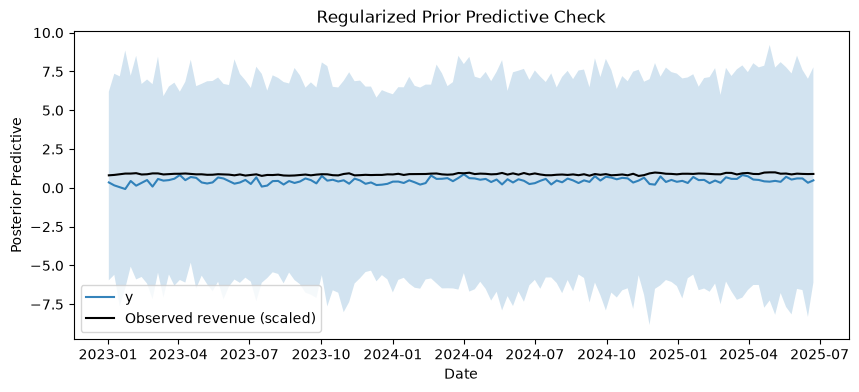

In [20]:
fig, axes = mmm_regularized.plot.prior_predictive(
    hdi_prob=0.94
)

ax = axes.flatten()[0]

ax.plot(
    X_train["date_week"],
    y_train / y_train.max(),
    color="black",
    linewidth=1.5,
    label="Observed revenue (scaled)",
)

ax.set_title("Regularized Prior Predictive Check")
ax.legend();

In [21]:
mmm_regularized.fit(
    X=X_train,
    y=y_train,
    chains=4,
    tune=1500,
    draws=1000,
    target_accept=0.99,
    random_seed=RANDOM_SEED,
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept_contribution, adstock_alpha, saturation_lam, saturation_beta, gamma_control, gamma_fourier, y_sigma]


Output()

Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 76 seconds.


Output()

Inference data with groups:
	> posterior
	> sample_stats
	> prior
	> prior_predictive
	> observed_data
	> constant_data
	> fit_data

In [22]:
diagnostic_vars = [
    "adstock_alpha",
    "saturation_lam",
    "saturation_beta",
    "gamma_control",
    "gamma_fourier",
    "y_sigma",
]

regularized_summary = az.summary(
    mmm_regularized.idata,
    var_names=diagnostic_vars,
    round_to=3,
)

display(
    regularized_summary[
        [
            "mean",
            "sd",
            "r_hat",
            "ess_bulk",
            "ess_tail",
        ]
    ]
)

print("BFMI by chain:")
print(az.bfmi(mmm_regularized.idata))

,mean,sd,r_hat,ess_bulk,ess_tail
adstock_alpha[tv_spend],0.363,0.110,1.001,3729.113,2394.416
adstock_alpha[google_search_spend],0.245,0.179,1.001,3104.579,1795.364
adstock_alpha[tiktok_spend],0.176,0.129,1.000,3228.786,1892.750
saturation_lam[tv_spend],2.690,0.910,1.001,2869.663,2469.990
saturation_lam[google_search_spend],2.995,1.078,1.001,3209.964,1903.699
saturation_lam[tiktok_spend],2.550,0.883,1.000,3076.013,2784.838
saturation_beta[tv_spend],0.085,0.031,1.001,2164.306,2585.245
saturation_beta[google_search_spend],0.074,0.044,1.002,1663.921,1686.463
saturation_beta[tiktok_spend],0.052,0.018,1.001,2721.737,2379.599
gamma_control[promotion],0.074,0.006,1.001,4506.264,2892.792


BFMI by chain:
[0.93171934 0.89450938 0.94932879 0.85055827]


### Review: MCMC Sampling Diagnostics

| Diagnostic | What it measures | Interpretation | Recommended response |
|---|---|---|---|
| **R-hat** | Compares within-chain and between-chain variation to assess whether multiple chains explored the same posterior distribution. | Values close to `1.00` are desirable. `R-hat < 1.01` is commonly treated as acceptable. A larger value suggests incomplete convergence or poor mixing. | Increase tuning, inspect trace plots, improve priors or scaling, reparameterize, or simplify the model. |
| **ESS bulk** | Estimates the effective number of independent samples in the central or high-probability region of the posterior. | A low value means strong autocorrelation and imprecise estimates of posterior means, medians, and standard deviations. Higher is better; several hundred is a rough minimum, while more than `1,000` is preferable when available. | Increase sampling only after checking mixing, parameter correlation, scaling, priors, and model geometry. |
| **ESS tail** | Estimates the effective number of independent samples in the posterior tails. | A low value means that tail probabilities, credible-interval endpoints, and extreme quantiles may be estimated unreliably. Higher is better; several hundred is a rough minimum. | Inspect skewed or heavy-tailed parameters, improve priors or parameterization, and increase draws only after addressing structural problems. |
| **Divergences** | Identify NUTS trajectories for which the numerical Hamiltonian integration becomes inaccurate, usually because of high curvature or difficult posterior geometry. | Post-warmup divergences should ideally be `0`. Even a small number can indicate biased exploration if they concentrate in an important posterior region. | Use pair plots to locate the problematic parameter combinations, inspect scaling and priors, increase `target_accept` modestly, reparameterize, or simplify the model. |

These diagnostics answer different questions:

- **R-hat:** Did the chains converge to the same posterior distribution?
- **ESS bulk:** Do I have enough effective samples for the center of the posterior?
- **ESS tail:** Do I have enough effective samples for credible intervals and tail quantities?
- **Divergences:** Did NUTS fail to explore any difficult posterior regions accurately?

ess_tail checks the effective sample size for the 5% and 95% quantiles and reports the smaller value.

These results indicate stable chain mixing, adequate effective sample sizes, and no detected divergent transitions.
### Bayesian Fraction of Missing Information (BFMI)

BFMI is an HMC/NUTS diagnostic that measures how effectively each chain explores the posterior energy distribution.

- A low BFMI means that the chain makes only small energy transitions relative to the full posterior energy range and may fail to explore some regions.
- BFMI below approximately `0.3` is commonly treated as a warning sign.
- Values near or above `1` generally indicate good energy exploration and may occasionally be slightly greater than `1`.

In [23]:
from pathlib import Path

MODEL_PATH = Path(
    "../artifacts/mmm_regularized.nc"
)

MODEL_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

mmm_regularized.save(MODEL_PATH)

print(f"Model saved to: {MODEL_PATH.resolve()}")

Model saved to: /Users/hl/Desktop/PythonProject1/pymc-marketing-retail-mmm/artifacts/mmm_regularized.nc
